## Importando as Biliotecas

In [12]:
import pandas as pd
import numpy as np
import re
import joblib

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import RSLPStemmer

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import (
    RandomizedSearchCV,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## Leitura da Base de Dados

In [3]:
dados = pd.read_csv("../data/dataset_tratado.csv", index_col=0)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,positivo
4,Parabéns lojas lannister adorei comprar pela I...,5,positivo
9,aparelho eficiente. no site a marca do aparelh...,4,positivo
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,positivo
15,"Vendedor confiável, produto ok e entrega antes...",5,positivo


* Transformando a coluna "Sentimento" em uma coluna Binária -> 0 (negativo) e 1 (positivo)

In [4]:
col_binaria = {
    "negativo": 0,
    "positivo": 1
}
dados["sentimento"] = dados["sentimento"].map(col_binaria)
dados.head()

,review_comment_message,review_score,sentimento
3,Recebi bem antes do prazo estipulado.,5,1
4,Parabéns lojas lannister adorei comprar pela I...,5,1
9,aparelho eficiente. no site a marca do aparelh...,4,1
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",4,1
15,"Vendedor confiável, produto ok e entrega antes...",5,1


# 1.Modelo TF-IDF

In [5]:
CONTRACTIONS = {
    'vc': 'você', 'tb': 'também', 'tbm': 'também', 'pq': 'por que', 'obg': 'obrigado', 'blz': 'beleza',
    'td': 'tudo', 'msm': 'mesmo', 'vlw': 'valeu', 'n': 'não', 'naum': 'não', 'cmprar': 'comprar',
    'mt': 'muito', 'pra': 'para'
}

STOP_WORDS = set(stopwords.words("portuguese"))
NEGACAO = {"não", "nao", "nunca", "nem", "sem"}
STOP_WORDS_PT = STOP_WORDS - NEGACAO

In [8]:
stemmer = RSLPStemmer()

def limpeza_tfidf(texto):

    # 1. Lowercase
    texto = texto.lower()

    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)

    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)

    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)

    # 5. Expande contrações
    palavras = [CONTRACTIONS.get(p, p) for p in texto.split()]

    texto = " ".join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéèêíìîóòôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    # 8. Tokenização
    tokens = word_tokenize(texto, language="portuguese")

    # 9. Stopwords + stemming
    resultado = []

    for token in tokens:

        if token.isalpha() and token not in STOP_WORDS_PT:
            token_stemmer = stemmer.stem(token)
            resultado.append(token_stemmer)

    return " ".join(resultado)


In [9]:
df_tfidf = dados.copy()
df_tfidf["review"] = df_tfidf["review_comment_message"].apply(limpeza_tfidf)
df_tfidf[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt ok entreg ant praz


## Previsão do Modelo

In [13]:
modelo_tfidf = joblib.load("../models/modelo_tfidf_final.pkl")

In [14]:
previsao_tfidf = modelo_tfidf.predict(df_tfidf["review"])

# 2. Modelo Bow + N-gram

In [15]:
df_bow_ngram = dados.copy()

df_bow_ngram["review"] = df_bow_ngram["review_comment_message"].apply(limpeza_tfidf)
df_bow_ngram[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,receb bem ant praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabém loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh efici sit marc aparelh impress desinfe...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc trav val ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vend confi produt ok entreg ant praz


## Previsão do Modelo

In [16]:
modelo_bow_ngram = joblib.load("../models/modelo_bow_ngram_final.pkl")

In [17]:
previsao_bow_ngram = modelo_bow_ngram.predict(df_bow_ngram["review"])

# 3. Modelo Embeddings

In [18]:
def limpeza_embedding(texto):

    # 1. Lowercase
    texto = texto.lower()

    # 2. Remove HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)

    # 3. Remove URLs
    texto = re.sub(r'http\S+|www\.\S+', ' ', texto)

    # 4. Remove e-mails
    texto = re.sub(r'\S+@\S+', ' ', texto)

    # 5. Expande contrações
    palavras = [CONTRACTIONS.get(p, p) for p in texto.split()]

    texto = " ".join(palavras)

    # 6. Remove caracteres indesejados
    texto = re.sub(r'[^a-záàâãéèêíìîóòôõöúùûüç\s.,!?]', ' ', texto)

    # 7. Normaliza espaços
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto


In [19]:
df_embedding = dados.copy()

df_embedding["review"] = df_embedding["review_comment_message"].apply(limpeza_embedding)
df_embedding[["review_comment_message", "review"]].head()

,review_comment_message,review
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado.
4,Parabéns lojas lannister adorei comprar pela I...,parabéns lojas lannister adorei comprar pela i...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente. no site a marca do aparelh...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n","mas um pouco ,travando...pelo valor ta boa."
15,"Vendedor confiável, produto ok e entrega antes...","vendedor confiável, produto ok e entrega antes..."


## Carregando o modelo de embedding

In [20]:
from sentence_transformers import SentenceTransformer

modelo_embedding = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [21]:
X_embeddings = modelo_embedding.encode(
    df_embedding["review"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

Batches:   0%|          | 0/585 [00:00<?, ?it/s]

## Carregando Modelo Salvo

In [22]:
modelo_embedding_final = joblib.load("../models/modelo_embeddings_final.pkl")

In [23]:
previsao_embedding = modelo_embedding_final.predict(X_embeddings)

# 4. Analisando Resultados Finais dos Modelos

In [29]:
print("=== Modelo TF-IDF ===\n")
print(classification_report(df_tfidf["sentimento"], previsao_tfidf))
print("-"*60)

print("\n=== Modelo Bow + Ngram ===\n")
print(classification_report(df_bow_ngram["sentimento"], previsao_bow_ngram))
print("-"*60)

print("\n=== Modelo Embeddings ===\n")
print(classification_report(df_embedding["sentimento"], previsao_embedding))
print("-"*60)

=== Modelo TF-IDF ===

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     10890
           1       0.98      0.94      0.96     26530

    accuracy                           0.95     37420
   macro avg       0.93      0.95      0.94     37420
weighted avg       0.95      0.95      0.95     37420

------------------------------------------------------------

=== Modelo Bow + Ngram ===

              precision    recall  f1-score   support

           0       0.86      0.94      0.90     10890
           1       0.97      0.94      0.95     26530

    accuracy                           0.94     37420
   macro avg       0.92      0.94      0.93     37420
weighted avg       0.94      0.94      0.94     37420

------------------------------------------------------------

=== Modelo Embeddings ===

              precision    recall  f1-score   support

           0       0.83      0.95      0.89     10890
           1       0.98      0.92  

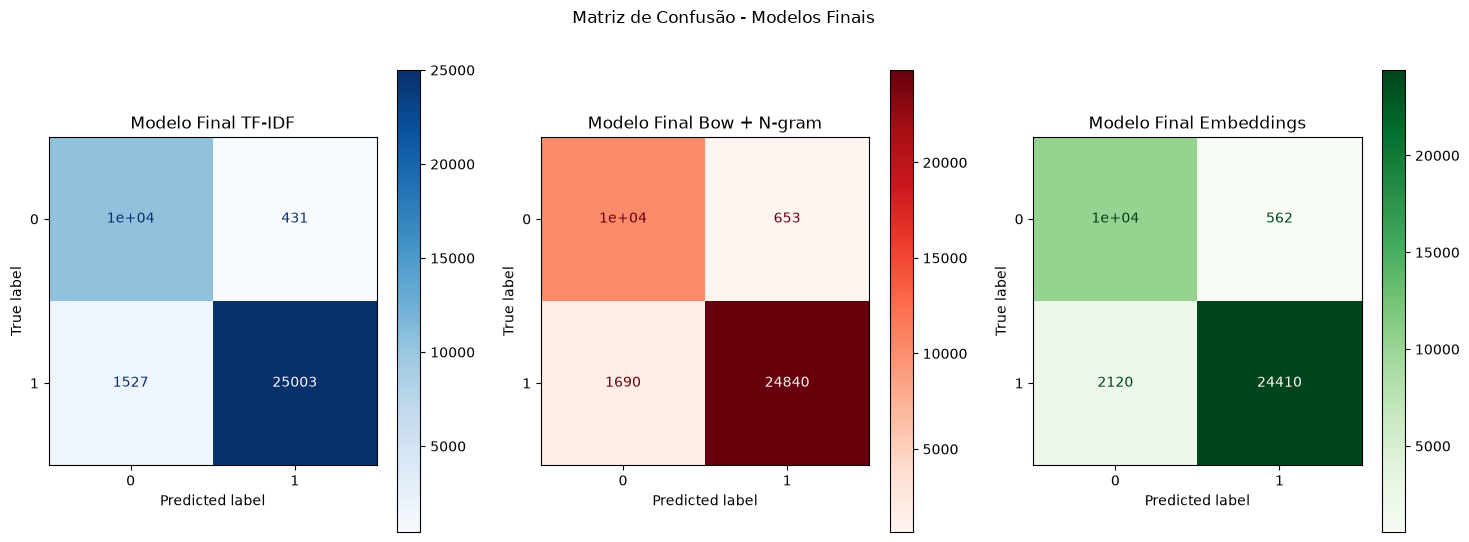

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))


ConfusionMatrixDisplay.from_predictions(df_tfidf["sentimento"], previsao_tfidf, cmap="Blues", ax=axes[0])
axes[0].set_title("Modelo Final TF-IDF")

ConfusionMatrixDisplay.from_predictions(df_bow_ngram["sentimento"], previsao_bow_ngram, cmap="Reds", ax=axes[1])
axes[1].set_title("Modelo Final Bow + N-gram")

ConfusionMatrixDisplay.from_predictions(df_embedding["sentimento"], previsao_embedding, cmap="Greens", ax=axes[2])
axes[2].set_title("Modelo Final Embeddings")

plt.suptitle("Matriz de Confusão - Modelos Finais")
plt.show()